<a href="https://colab.research.google.com/github/tmedeirosb/tsi-ad-2025/blob/main/exemplos_un6_pre_processamento.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np

dados = {
    'Idade': [25, 30, 35, np.nan],
    'Peso': [70, 80, np.nan, 65],
    'Altura': [175, np.nan, 185, 160]
}

df = pd.DataFrame(dados)
print("--- 1. DataFrame Original ---")
display(df)

mascara_nulos = df.isna()
print("\n--- 2. Saída do isna() ---")
display(mascara_nulos)

df_exclusao_linhas = df.dropna()
print("\n--- 3. Saída do dropna() (Padrão: remove linhas) ---")
display(df_exclusao_linhas)

df_imputado = df.fillna(df.mean())
print("\n--- 4. Saída do fillna() (Preenchendo com a média) ---")
display(df_imputado)

--- 1. DataFrame Original ---


,Idade,Peso,Altura
0,25.0,70.0,175.0
1,30.0,80.0,NaN
2,35.0,NaN,185.0
3,NaN,65.0,160.0



--- 2. Saída do isna() ---


,Idade,Peso,Altura
0,False,False,False
1,False,False,True
2,False,True,False
3,True,False,False



--- 3. Saída do dropna() (Padrão: remove linhas) ---


,Idade,Peso,Altura
0,25.0,70.0,175.0



--- 4. Saída do fillna() (Preenchendo com a média) ---


,Idade,Peso,Altura
0,25.0,70.000000,175.000000
1,30.0,80.000000,173.333333
2,35.0,71.666667,185.000000
3,30.0,65.000000,160.000000


In [ ]:
import pandas as pd
import numpy as np

dados = {
    'Nome': ['Ana', 'Bruno', 'Carlos', 'Daniela', 'Eduardo', 'Fabio'],
    'Idade': [28, -28, 35, -1, 40, -50], # -1 é ausente, -28 e -50 são erros de digitação
    'CPF': [
        '123.456.789-00',
        '12345678900',
        '111.222.333-44',
        '999.888.777-66',
        '55566677788',
        '000.111.222-33'
    ]
}

df = pd.DataFrame(dados)

print("--- 1. DataFrame Original ---")
display(df)

# Passo A: Limpeza do CPF (Padrão: apenas números)
df['CPF'] = df['CPF'].replace(r'\D', '', regex=True)

# Passo B: Regra de Negócios da Idade
# 1º: Tratamos a exceção (-1 vira NaN)
df['Idade'] = df['Idade'].replace(-1, np.nan)

# 2º: Tratamos o restante dos negativos (transforma -28 em 28, -50 em 50)
# A função .abs() calcula o valor absoluto. O Pandas é inteligente
# o suficiente para ignorar o NaN que acabamos de criar.
df['Idade'] = df['Idade'].abs()

print("\n--- 2. DataFrame Final (Tratado) ---")
display(df)

--- 1. DataFrame Original ---


,Nome,Idade,CPF
0,Ana,28,123.456.789-00
1,Bruno,-28,12345678900
2,Carlos,35,111.222.333-44
3,Daniela,-1,999.888.777-66
4,Eduardo,40,55566677788
5,Fabio,-50,000.111.222-33



--- 2. DataFrame Final (Tratado) ---


,Nome,Idade,CPF
0,Ana,28.0,12345678900
1,Bruno,28.0,12345678900
2,Carlos,35.0,11122233344
3,Daniela,NaN,99988877766
4,Eduardo,40.0,55566677788
5,Fabio,50.0,00011122233


In [ ]:
import pandas as pd

# 1. Criando um DataFrame com duplicatas propositais
# Cenário: Um log de atualizações de funcionários
dados = {
    'ID': [101, 101, 102, 103, 103],
    'Nome': ['Ana', 'Ana', 'Bruno', 'Carlos', 'Carlos'],
    'Departamento': ['TI', 'TI', 'RH', 'Vendas', 'Vendas'],
    'Data_Atualizacao': ['2023-01-01', '2023-01-01', '2023-05-10', '2023-02-01', '2023-12-15']
}

df = pd.DataFrame(dados)

print("--- 1. DataFrame Original ---")
print("Observe: Ana tem linhas idênticas. Carlos tem o mesmo ID/Dept, mas datas diferentes.")
display(df)

# --- A. DETECTANDO DUPLICATAS ---
# duplicated() retorna uma Série Booleana (True se for duplicado, False se for único)
# Por padrão, ela marca a *primeira* ocorrência como False e as seguintes como True.
duplicados_check = df.duplicated()

print("\n--- 2. Saída de df.duplicated() ---")
print("Retorna True apenas para as linhas que são cópias exatas de anteriores:")
print(duplicados_check)


# --- B. REMOVENDO DUPLICATAS EXATAS ---
# drop_duplicates() simples remove linhas onde TODAS as colunas são iguais.
# No nosso caso, vai remover a segunda linha da 'Ana'.
# O 'Carlos' não é removido aqui porque a 'Data_Atualizacao' é diferente.
df_sem_exatas = df.drop_duplicates()

print("\n--- 3. Saída de df.drop_duplicates() (Padrão) ---")
print("A cópia exata da Ana sumiu, mas as duas versões do Carlos continuam:")
display(df_sem_exatas)


# --- C. REMOVENDO COM SUBSET E KEEP='LAST' ---
# Aqui queremos remover duplicatas baseadas apenas no 'ID' e 'Departamento' (subset).
# keep='last' significa: "Se encontrar repetidos, mantenha apenas o último que aparecer".
# Isso é muito útil para pegar o dado "mais recente" de uma lista desordenada.
df_tratado_final = df.drop_duplicates(
    subset=["ID", "Departamento"],
    keep="last"
)

print("\n--- 4. Saída de drop_duplicates(['ID', 'Dept'], keep='last') ---")
print("Note que para o Carlos, ficou a linha de 2023-12-15 (a última):")
display(df_tratado_final)

--- 1. DataFrame Original ---
Observe: Ana tem linhas idênticas. Carlos tem o mesmo ID/Dept, mas datas diferentes.


,ID,Nome,Departamento,Data_Atualizacao
0,101,Ana,TI,2023-01-01
1,101,Ana,TI,2023-01-01
2,102,Bruno,RH,2023-05-10
3,103,Carlos,Vendas,2023-02-01
4,103,Carlos,Vendas,2023-12-15



--- 2. Saída de df.duplicated() ---
Retorna True apenas para as linhas que são cópias exatas de anteriores:
0    False
1     True
2    False
3    False
4    False
dtype: bool

--- 3. Saída de df.drop_duplicates() (Padrão) ---
A cópia exata da Ana sumiu, mas as duas versões do Carlos continuam:


,ID,Nome,Departamento,Data_Atualizacao
0,101,Ana,TI,2023-01-01
2,102,Bruno,RH,2023-05-10
3,103,Carlos,Vendas,2023-02-01
4,103,Carlos,Vendas,2023-12-15



--- 4. Saída de drop_duplicates(['ID', 'Dept'], keep='last') ---
Note que para o Carlos, ficou a linha de 2023-12-15 (a última):


,ID,Nome,Departamento,Data_Atualizacao
1,101,Ana,TI,2023-01-01
2,102,Bruno,RH,2023-05-10
4,103,Carlos,Vendas,2023-12-15


--- 1. Distribuição Original ---
Contagem: Counter({np.int64(0): 895, np.int64(1): 105})


,Feature_A,Feature_B,Target
0,0.873546,-0.901339,0
1,0.555945,-0.972352,0
2,1.154479,-0.748528,0
3,2.903090,0.433485,0
4,1.751888,-0.070157,0



--- 2. Após UNDERSAMPLING ---
Nota: A classe 0 foi cortada drasticamente.
Nova Contagem: Counter({np.int64(0): 105, np.int64(1): 105})

--- 3. Após OVERSAMPLING ---
Nota: A classe 1 cresceu (repetição de dados).
Nova Contagem: Counter({np.int64(0): 895, np.int64(1): 895})


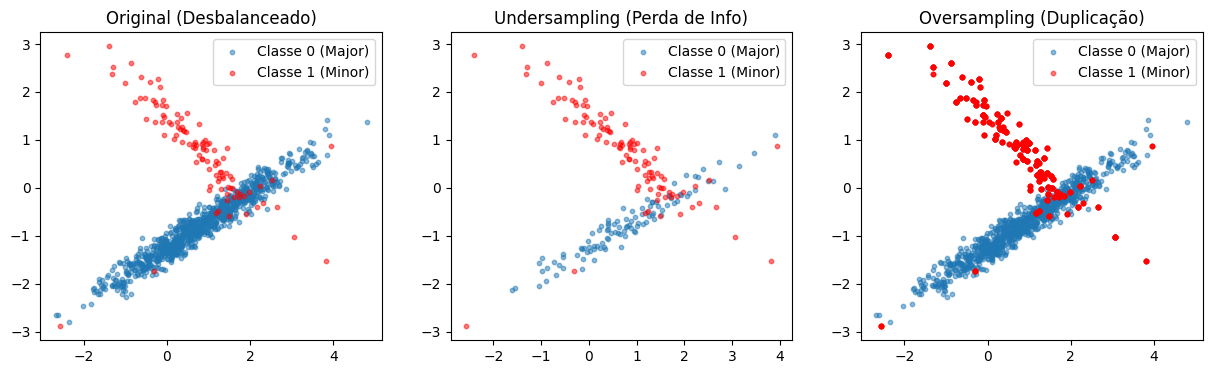

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
from sklearn.datasets import make_classification
from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import RandomOverSampler

# 1. Gerando um Dataset Sintético Desbalanceado
# weights=[0.90, 0.10] cria 90% da classe 0 e 10% da classe 1
X, y = make_classification(n_samples=1000, n_features=2, n_informative=2,
                           n_redundant=0, n_repeated=0, n_classes=2,
                           n_clusters_per_class=1,
                           weights=[0.90, 0.10],
                           class_sep=0.8, random_state=42)

print(f"--- 1. Distribuição Original ---")
print(f"Contagem: {Counter(y)}")
# Vamos colocar em um DataFrame apenas para visualizar melhor o head
df_original = pd.DataFrame(X, columns=['Feature_A', 'Feature_B'])
df_original['Target'] = y
display(df_original.head())


# --- TÉCNICA A: UNDERSAMPLING (Subamostragem) ---
# Estratégia: Reduzir a classe majoritária (0) para ter o mesmo tamanho da minoritária (1)
rus = RandomUnderSampler(random_state=42)
X_res_under, y_res_under = rus.fit_resample(X, y)

print(f"\n--- 2. Após UNDERSAMPLING ---")
print(f"Nota: A classe 0 foi cortada drasticamente.")
print(f"Nova Contagem: {Counter(y_res_under)}")


# --- TÉCNICA B: OVERSAMPLING (Superamostragem) ---
# Estratégia: Duplicar a classe minoritária (1) até atingir o tamanho da majoritária (0)
ros = RandomOverSampler(random_state=42)
X_res_over, y_res_over = ros.fit_resample(X, y)

print(f"\n--- 3. Após OVERSAMPLING ---")
print(f"Nota: A classe 1 cresceu (repetição de dados).")
print(f"Nova Contagem: {Counter(y_res_over)}")

# --- VISUALIZAÇÃO GRÁFICA (Opcional para ver a densidade) ---
def plot_distribuicao(X, y, titulo):
    plt.scatter(X[y == 0, 0], X[y == 0, 1], label="Classe 0 (Major)", alpha=0.5, s=10)
    plt.scatter(X[y == 1, 0], X[y == 1, 1], label="Classe 1 (Minor)", color='red', alpha=0.5, s=10)
    plt.title(titulo)
    plt.legend()

plt.figure(figsize=(15, 4))

plt.subplot(1, 3, 1)
plot_distribuicao(X, y, "Original (Desbalanceado)")

plt.subplot(1, 3, 2)
plot_distribuicao(X_res_under, y_res_under, "Undersampling (Perda de Info)")

plt.subplot(1, 3, 3)
plot_distribuicao(X_res_over, y_res_over, "Oversampling (Duplicação)")

plt.show()

In [ ]:
import pandas as pd
import numpy as np

# 1. Criando um DataFrame com notas variadas (incluindo bordas como 0, 5.0 e 10)
data = {
    'Aluno': ['Ana', 'Bruno', 'Carlos', 'Daniela', 'Eduardo', 'Fabio'],
    'Media_Final': [9.5, 4.9, 5.0, 7.2, 10.0, 0.0]
}

df = pd.DataFrame(data)

print("--- 1. Notas Originais ---")
display(df)

# --- APLICAÇÃO DO BINNING (Discretização) ---

# Definindo as faixas de corte (Bins)
# Lógica:
# 0 a 4.9 -> D (Reprovado)
# 5.0 a 6.9 -> C
# 7.0 a 8.9 -> B
# 9.0 a 10.0 -> A
bins_limites = [0, 4.99, 6.99, 8.99, 10.0]

# Definindo os Rótulos (Labels) - Deve ter 1 rótulo a menos que os limites
labels_conceitos = ['D', 'C', 'B', 'A']

# Criando a coluna nova
# include_lowest=True: Garante que o zero (0.0) seja incluído na primeira faixa.
df['Conceito'] = pd.cut(
    df['Media_Final'],
    bins=bins_limites,
    labels=labels_conceitos,
    include_lowest=True
)

print("\n--- 2. Com a Coluna Discretizada ---")
display(df)

--- 1. Notas Originais ---


,Aluno,Media_Final
0,Ana,9.5
1,Bruno,4.9
2,Carlos,5.0
3,Daniela,7.2
4,Eduardo,10.0
5,Fabio,0.0



--- 2. Com a Coluna Discretizada ---


,Aluno,Media_Final,Conceito
0,Ana,9.5,A
1,Bruno,4.9,D
2,Carlos,5.0,C
3,Daniela,7.2,B
4,Eduardo,10.0,A
5,Fabio,0.0,D


In [ ]:
import pandas as pd

# 1. Criando um DataFrame com as categorias do IBGE
# Incluí um exemplo de cada para a matriz ficar completa
dados = {
    'Candidato': ['Ana', 'Beto', 'Carla', 'Daniel', 'Eliana', 'Fabio'],
    'Cor_Raca': [
        'Branca',    # Exemplo 1
        'Parda',     # Exemplo 2
        'Preta',     # Exemplo 3
        'Amarela',   # Exemplo 4
        'Indígena',  # Exemplo 5
        'Parda'      # Repetição para mostrar como fica
    ]
}

df = pd.DataFrame(dados)

print("--- 1. DataFrame Original (Categórico) ---")
display(df)

# --- CRIANDO A MATRIZ DUMMY ---

# columns=['Cor_Raca']: Especifica qual coluna transformar
# prefix='IBGE': Adiciona um prefixo para saber de onde veio a coluna (Ex: IBGE_Branca)
# dtype=int: Força a saída ser 0 e 1 (em versões novas do Pandas, o padrão virou True/False)

df_dummies = pd.get_dummies(
    df,
    columns=['Cor_Raca'],
    prefix='IBGE',
    dtype=int,
    drop_first=True,  # <--- EVITAR Colinearidade
)

print("\n--- 2. DataFrame com Matriz Dummy (One-Hot Encoding) ---")
display(df_dummies)

--- 1. DataFrame Original (Categórico) ---


,Candidato,Cor_Raca
0,Ana,Branca
1,Beto,Parda
2,Carla,Preta
3,Daniel,Amarela
4,Eliana,Indígena
5,Fabio,Parda



--- 2. DataFrame com Matriz Dummy (One-Hot Encoding) ---


,Candidato,IBGE_Branca,IBGE_Indígena,IBGE_Parda,IBGE_Preta
0,Ana,1,0,0,0
1,Beto,0,0,1,0
2,Carla,0,0,0,1
3,Daniel,0,0,0,0
4,Eliana,0,1,0,0
5,Fabio,0,0,1,0


In [ ]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

# Dados: Notas do "Vestibular" (Escala 0 a 1000)
dados_alunos = {
    'Aluno': ['Ana', 'Bruno', 'Carlos', 'Daniela', 'Eduardo'],
    'Nota_Vestibular': [350, 980, 700, 410, 850] # Variância alta
}

df_escola = pd.DataFrame(dados_alunos)

print("--- 1. Notas Originais (0 a 1000) ---")
display(df_escola)

# --- APLICANDO MIN-MAX SCALER ---
# Inicializa o escalonador
scaler = MinMaxScaler()

# O fit_transform espera um array 2D, por isso usamos df[['coluna']] com colchetes duplos
df_escola['Nota_Escalonada'] = scaler.fit_transform(df_escola[['Nota_Vestibular']])

print("\n--- 2. Notas Escalonadas (0 a 1) ---")
print("Note que a menor nota (350) virou 0.0 e a maior (980) virou 1.0")
display(df_escola)

--- 1. Notas Originais (0 a 1000) ---


,Aluno,Nota_Vestibular
0,Ana,350
1,Bruno,980
2,Carlos,700
3,Daniela,410
4,Eduardo,850



--- 2. Notas Escalonadas (0 a 1) ---
Note que a menor nota (350) virou 0.0 e a maior (980) virou 1.0


,Aluno,Nota_Vestibular,Nota_Escalonada
0,Ana,350,0.000000
1,Bruno,980,1.000000
2,Carlos,700,0.555556
3,Daniela,410,0.095238
4,Eduardo,850,0.793651


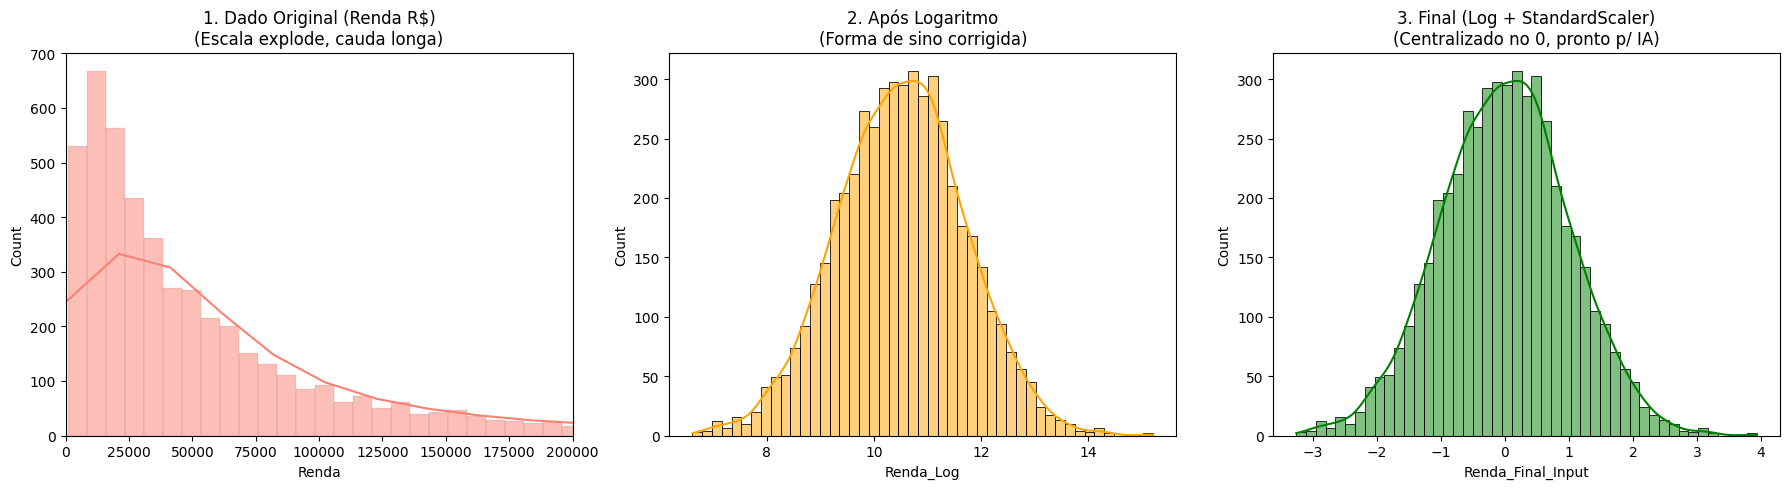

--- Amostra dos Dados Transformados ---


,Renda,Renda_Log,Renda_Final_Input
0,65910.759918,11.096072,0.492890
1,30763.458079,10.334115,-0.144417
2,79001.826049,11.277239,0.644419
3,225852.142560,12.327640,1.522983
4,27419.670886,10.219052,-0.240656



--- Estatísticas Finais ---
count    5000.00
mean       -0.00
std         1.00
min        -3.26
25%        -0.67
50%         0.01
75%         0.66
max         3.94
Name: Renda_Final_Input, dtype: float64


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

# 1. GERANDO DADOS (Simulação de Renda com distribuição exponencial)
np.random.seed(42)
dados = np.random.lognormal(mean=10.5, sigma=1.2, size=5000)
df = pd.DataFrame({'Renda': dados})

# Passo 1: Transformação Logarítmica (Para corrigir a assimetria/curva)
# Usamos log1p (log de x+1) por segurança contra zeros
df['Renda_Log'] = np.log1p(df['Renda'])

# Passo 2: Padronização (Para colocar na escala ideal da Rede Neural)
scaler = StandardScaler()
# O fit_transform espera um formato 2D, por isso os colchetes duplos [['...']]
df['Renda_Final_Input'] = scaler.fit_transform(df[['Renda_Log']])

# --- VISUALIZAÇÃO ---
fig, ax = plt.subplots(1, 3, figsize=(18, 5))

# Gráfico 1: Original (Exponencial)
sns.histplot(df['Renda'], kde=True, ax=ax[0], color='salmon')
ax[0].set_title('1. Dado Original (Renda R$)\n(Escala explode, cauda longa)')
ax[0].set_xlim(0, 200000) # Zoom para ver melhor

# Gráfico 2: Apenas Log (Normalizado)
sns.histplot(df['Renda_Log'], kde=True, ax=ax[1], color='orange')
ax[1].set_title('2. Após Logaritmo\n(Forma de sino corrigida)')

# Gráfico 3: Final (Padronizado)
sns.histplot(df['Renda_Final_Input'], kde=True, ax=ax[2], color='green')
ax[2].set_title('3. Final (Log + StandardScaler)\n(Centralizado no 0, pronto p/ IA)')

plt.tight_layout()
plt.show()

# Mostrando os valores numéricos
print("--- Amostra dos Dados Transformados ---")
display(df.head())

print("\n--- Estatísticas Finais ---")
print(df['Renda_Final_Input'].describe().round(2))